In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as sc

base_path = Path.cwd()

data_path = base_path / 'Data' / 'Datasheet.xlsx'
img_path = base_path.parent.parent / '31' / 'Images'

Data50Tab = pd.read_excel(data_path, sheet_name='T = 50°C',engine='openpyxl')
Data48Tab = pd.read_excel(data_path, sheet_name='T = 48°C',engine='openpyxl')
Data45Tab = pd.read_excel(data_path, sheet_name='T = 45 °C',engine='openpyxl')
Data42Tab = pd.read_excel(data_path, sheet_name='T = 42°C',engine='openpyxl')
Data40Tab = pd.read_excel(data_path, sheet_name='T = 40°C',engine='openpyxl')
Data35Tab = pd.read_excel(data_path, sheet_name='T = 35°C',engine='openpyxl')
Data30Tab = pd.read_excel(data_path, sheet_name='T = 30 °C',engine='openpyxl')

Data30 = np.array([[x,y] for x,y in zip(Data30Tab['Druck [10^5 Pa]'].tolist(), Data30Tab['Volumen [ml]'].tolist())])
Data35 = np.array([[x,y] for x,y in zip(Data35Tab['Druck [10^5 Pa]'].tolist(), Data35Tab['Volumen [ml]'].tolist())])
Data40 = np.array([[x,y] for x,y in zip(Data40Tab['Druck [10^5 Pa]'].tolist(), Data40Tab['Volumen [ml]'].tolist())])
Data42 = np.array([[x,y] for x,y in zip(Data42Tab['Druck [10^5 Pa]'].tolist(), Data42Tab['Volumen [ml]'].tolist())])
Data45 = np.array([[x,y] for x,y in zip(Data45Tab['Druck [10^5 Pa]'].tolist(), Data45Tab['Volumen [ml]'].tolist())])
Data48 = np.array([[x,y] for x,y in zip(Data48Tab['Druck [10^5 Pa]'].tolist(), Data48Tab['Volumen [ml]'].tolist())])
Data50 = np.array([[x,y] for x,y in zip(Data50Tab['Druck [10^5 Pa]'].tolist(), Data50Tab['Volumen [ml]'].tolist())])

MGS = np.array([[24.0, 0.25], [27.5, 0.25], [30.5, 0.250], [32.25, 0.25], [34.5, 0.25], [37.5, 0.30]])
MGE = np.array([[24.0, 0.75], [27.25, 0.75], [30.5, 0.6], [32, 0.55], [34.5, 0.45], [37.5, 0.35]])

DP = 0.025 # Fehler Druck in 10^5 Pa
DV = 0.025 # Fehler Volumen in ml


zum einzel plot

In [3]:
def pVPlot(T, Data, vdw=True, hert=0, ylim=30, xlim=4):
    plt.errorbar(Data[:,1], Data[:,0], fmt='x', label=f'T = {T} °C', xerr=0.025, yerr=0.03, color='black')
    if vdw:
        plt.hlines(y=hert, color='red', linestyle='--', xmin=-1, xmax=5, linewidth=0.8, label='Maxwell')
    plt.xlabel('Volumen [ml]')
    plt.ylabel('Druck [10$^5$ Pa]')
    plt.title(f'p V Relation bei {T}°C', loc='left')
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
    plt.xticks(np.arange(0, xlim+1, 0.5))
    plt.yticks(np.arange(0, ylim+1, 5))
    plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
    plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
    plt.xlim(0, xlim)
    plt.ylim(0, ylim)
    plt.legend()
    plt.savefig(img_path / 'pV' /f'pV_T{T}.png', bbox_inches='tight')

## gesamtplot der Messungen

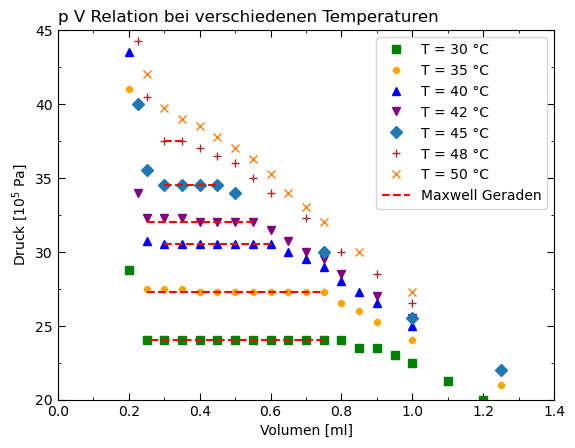

In [4]:
plt.plot(Data30[:,1], Data30[:,0], 's', label='T = 30 °C', color='green')
plt.hlines(y=24, color='red', linestyle='--', xmin=0.75, xmax=0.25, linewidth=1.5)
plt.plot(Data35[:,1], Data35[:,0], '8', label='T = 35 °C', color='orange', markersize=4)
plt.hlines(y=27.25, color='red', linestyle='--', xmin=0.25, xmax=0.75, linewidth=1.5)
plt.plot(Data40[:,1], Data40[:,0], '^', label='T = 40 °C', color='blue')
plt.hlines(y=30.5, color='red', linestyle='--', xmin=0.3, xmax=0.6, linewidth=1.5)
plt.plot(Data42[:,1], Data42[:,0], 'v', label='T = 42 °C', color='purple')
plt.hlines(y=32, color='red', linestyle='--', xmin=0.25, xmax=0.55, linewidth=1.5)
plt.plot(Data45[:,1], Data45[:,0], 'D', label='T = 45 °C')
plt.hlines(y=34.5, color='red', linestyle='--', xmin=0.3, xmax=0.45, linewidth=1.5)
plt.plot(Data48[:,1], Data48[:,0], '+', label='T = 48 °C', color='brown')
plt.plot(Data50[:,1], Data50[:,0], 'x', label='T = 50 °C')
plt.hlines(y=37.5, color='red', linestyle='--', xmin=0.3, xmax=0.35, linewidth=1.5, label='Maxwell Geraden')
plt.xlabel('Volumen [ml]')
plt.ylabel('Druck [10$^5$ Pa]')
plt.title('p V Relation bei verschiedenen Temperaturen', loc='left')
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(0, 5, 0.2))
plt.yticks(np.arange(0, 60, 5))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
plt.xlim(0, 1.4)
plt.ylim(20, 45)
plt.legend()
plt.savefig(img_path / 'pV_all.png', bbox_inches='tight')

Fit an pK um kritischen Punkt zu finden

Fitparameter Startpunkte Maxwell Geraden: [155.  -9.]
Fitparameter Endpunkte Maxwell Geraden: [-29.66019417  48.01294498]
Intersection point: ( 0.30874518051065675 , 38.855502979150536 )


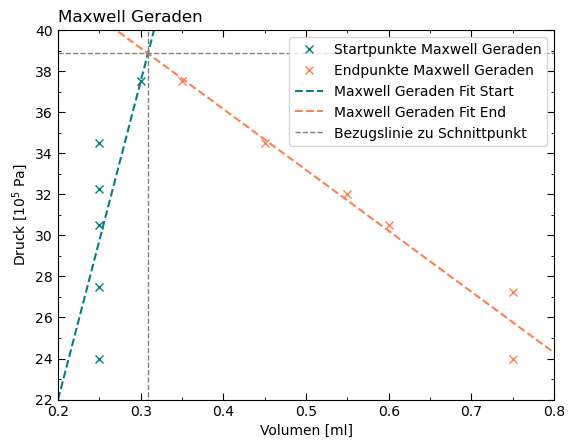

In [5]:
def lin(x,a,b):
    return a*x + b

paramsS, covS = sc.curve_fit(lin, MGS[:,1], MGS[:,0])
errorsS = np.sqrt(np.diag(covS))
paramsE, covE = sc.curve_fit(lin, MGE[:,1], MGE[:,0])
errorsE = np.sqrt(np.diag(covE))

aS, bS = paramsS
aE, bE = paramsE
x_int = (bE - bS) / (aS - aE)
y_int = aS * x_int + bS

print('Fitparameter Startpunkte Maxwell Geraden:', paramsS)
print('Fitparameter Endpunkte Maxwell Geraden:', paramsE)
print("Intersection point: (", x_int, ",", y_int, ")")

plt.plot(MGS[:,1], MGS[:,0], linestyle='none', marker='x', label='Startpunkte Maxwell Geraden', color='teal')
plt.plot(MGE[:,1], MGE[:,0], linestyle='none', marker='x', label='Endpunkte Maxwell Geraden', color='coral')
plt.plot(np.linspace(0.2,0.8,100), lin(np.linspace(0.2,0.8,100), *paramsS), label='Maxwell Geraden Fit Start', linestyle='--', color='teal')
plt.plot(np.linspace(0.2,0.8,100), lin(np.linspace(0.2,0.8,100), *paramsE), label='Maxwell Geraden Fit End', linestyle='--', color='coral')
plt.hlines(y=y_int, color='gray', linestyle='--', xmin=0, xmax=1, linewidth=1, label='Bezugslinie zu Schnittpunkt')
plt.vlines(x=x_int, color='gray', linestyle='--', ymin=20, ymax=45, linewidth=1)
plt.xlabel('Volumen [ml]')
plt.ylabel('Druck [10$^5$ Pa]')
plt.title('Maxwell Geraden', loc='left')
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(0, 1, 0.1))
plt.yticks(np.arange(20, 42, 2))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
plt.xlim(0.2, 0.8)
plt.ylim(22, 40)
plt.legend()
plt.savefig(img_path / 'Maxwell_Geraden.png', bbox_inches='tight')

## kritische Temperatur mit Dampfdruckkurve

Fitparameter Dampfdruckkurve: [-2375.55912989    11.01082119]
1/(Kritische Temperatur:) 273.1530944173867 K == 0.00309441738667748 °C
kritische Temperatur:


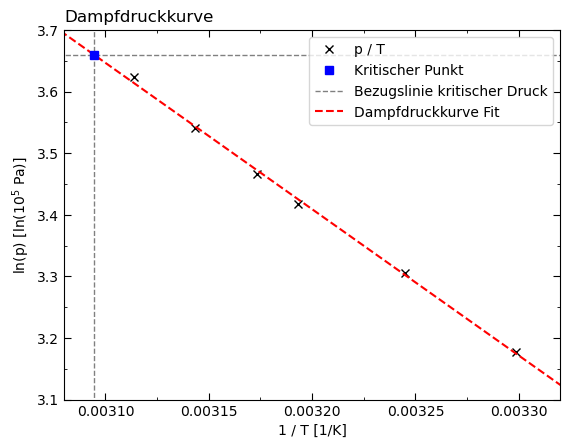

In [6]:
# Dampfdruckkurve implimentieren
DataPT = np.array([[24, 303.15], [27.25, 308.15], [30.5, 313.15], [32, 315.15], [34.5, 318.15], [37.5, 321.15]])

paramsPT, covPT = sc.curve_fit(lin, 1/DataPT[:,1], np.log(DataPT[:,0]))
errorsPT = np.sqrt(np.diag(covPT))
aPT, bPT = paramsPT
print('Fitparameter Dampfdruckkurve:', paramsPT)

TK = (np.log(y_int) - bPT)*1/aPT
print('1/(Kritische Temperatur:)', TK+273.15, 'K ==', TK, '°C')
print('kritische Temperatur:')

plt.plot(1/DataPT[:,1], np.log(DataPT[:,0]), 'x', label='p / T', color='black')
plt.plot(TK, np.log(y_int), 's', label='Kritischer Punkt', color='blue', zorder=5)
plt.hlines(y=np.log(y_int), color='gray', linestyle='--', xmin=0.0, xmax=0.0034, linewidth=1, label='Bezugslinie kritischer Druck')
plt.vlines(x=TK, color='gray', linestyle='--', ymin=0, ymax=4, linewidth=1)
plt.plot(np.linspace(0.003, 0.0034, 100), lin(np.linspace(0.003, 0.0034, 100), *paramsPT), label='Dampfdruckkurve Fit', linestyle='--', color='red')

plt.xlabel('1 / T [1/K]')
plt.ylabel('ln(p) [ln(10$^5$ Pa)]')
plt.title('Dampfdruckkurve', loc='left')
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(0.002, 0.0035, 0.00005))
plt.yticks(np.arange(3, 4, 0.1))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
plt.xlim(0.00308, 0.00332)
plt.ylim(3.1, 3.7)
plt.legend()
plt.savefig(img_path / 'Dampfdruckkurve.png', bbox_inches='tight')
plt.show()

In [7]:
TK += 273.15

Fitparameter pV bei T = 47,6 °C: [-9.18874703 35.68023101]


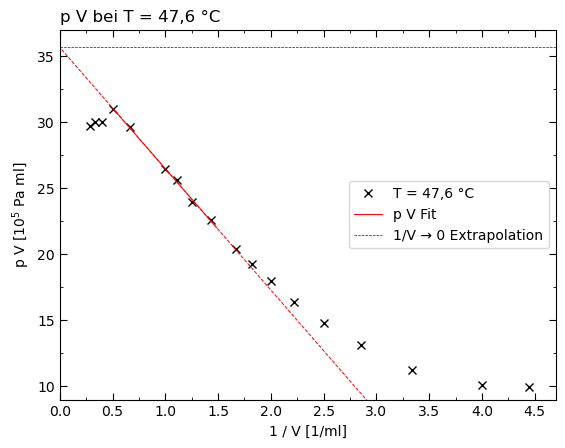

In [ ]:
# für 47,6 °C gibt es Data48
pV48 = np.array([Data48[i][0] * Data48[i][1] for i in range(len(Data48))])
Vinv48 = np.array([1/Data48[i][1] for i in range(len(Data48))])

limp = 1.5
limm = 0.5

mask = (Vinv48 <= limp) & (Vinv48 >= limm)
paramPV48, covPV48 = sc.curve_fit(lin, Vinv48[mask], pV48[mask])
errorsPV48 = np.sqrt(np.diag(covPV48))
aPV48, bPV48 = paramPV48

fitRange = np.linspace(-1, 5, 100)
maskF = (fitRange <= limp) & (fitRange >= limm)

print('Fitparameter pV bei T = 47,6 °C:', paramPV48)

plt.plot(Vinv48, pV48, 'x', label='T = 47,6 °C', color='black')
plt.plot(fitRange[maskF], lin(fitRange[maskF], *paramPV48), label='p V Fit', linestyle='-', color='red', linewidth=0.7)
plt.plot(fitRange[~maskF], lin(fitRange[~maskF], *paramPV48), label='_nolegend_', linestyle='--', color='red', linewidth=0.7)
# plt.vlines(x=limm, color='gray', linestyle='--', ymin=0, ymax=40, linewidth=0.5, label='Fitbereich')
# plt.vlines(x=limp, color='gray', linestyle='--', ymin=0, ymax=40, linewidth=0.5)
plt.hlines(y=bPV48, color='blue', linestyle='--', xmin=0, xmax=6, linewidth=0.5, label='1/V → 0 Extrapolation')
plt.legend(loc='center right')
plt.xlabel('1 / V [1/ml]')
plt.ylabel('p V [10$^5$ Pa ml]')
plt.title('p V bei T = 47,6 °C', loc='left')

plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(-1, 6, 0.5))
plt.yticks(np.arange(5, 40, 5))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
plt.xlim(0, 4.7)
plt.ylim(9, 37)
plt.savefig(img_path / 'pV48C.png', bbox_inches='tight')
plt.show()

In [9]:
# Stoffmenge berechnen
R = 8.3145  # J/(mol K)
T = 47.6 + 273.15  # K
n = bPV48 / (R * T)  # mol
print('Stoffmenge n bei T = 47,6 °C:', n, 'mol') # bPV48 ist nicht in SI Einheiten !!!!

Stoffmenge n bei T = 47,6 °C: 0.013379037001075973 mol


## bastis werte importieren

In [10]:
Pk = 38.5 , 4.0 # 10^5 Pa
Vk = 0.32 , 0.13 # ml
h = 20.91 , 0.50  # kJ 
Tk = 321, 11 # K

In [15]:
a = 27/64 * R**2 * (Tk[0])**2 / Pk[0], 27/64 * R**2 * (Tk[0]) / Pk[0] * np.sqrt((2*Tk[1])**2 + (Tk[0]/Pk[0] * Pk[1])**2)
print('Van der Waals a:', a, 'J^2 ml / mol^2')

b = R * Tk[0] / (8 * Pk[0]), 1/8 * R/Pk[0] * np.sqrt((Tk[1])**2 + (Tk[0]/Pk[0] * Pk[1])**2)
print('Van der Waals b:', b, 'ml / mol')

K = R * Tk[0] / (Pk[0]*Vk[0]), np.sqrt(
    (R / (Pk[0] * Vk[0]) * Tk[1])**2 +
    (R * Tk[0] / (Pk[0]**2 * Vk[0]) * Pk[1])**2 +
    (R * Tk[0] / (Pk[0] * Vk[0]**2) * Vk[1])**2
)
print('Kompressibilitätsfaktor K:', K)

Van der Waals a: (78055.83982260422, 9715.227492043348) J^2 ml / mol^2
Van der Waals b: (8.66543668831169, 0.948011852978022) ml / mol
Kompressibilitätsfaktor K: (216.63591720779223, 91.14368982986309)
